# NLP-Based Movie Genre Classification Using TF-IDF and Machine Learning

## Project Overview

This project aims to automatically classify movies into different genres based on their descriptions using Natural Language Processing (NLP) and Machine Learning.

The movie descriptions are first preprocessed and converted into numerical features using TF-IDF. Two machine learning algorithms, Logistic Regression and Multinomial Naive Bayes, are then trained and evaluated for movie genre classification.

## Step 1: Import Required Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

print("Libraries imported successfully.")

Libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 2: Upload Dataset


In [ ]:
uploaded = files.upload()

Saving Movies_Genre_Description.csv to Movies_Genre_Description.csv


## 3. Load Dataset

In [45]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Dataset Overview

In [46]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (108414, 4)

Column Names:
['TITLE', 'GENRE', 'DESCRIPTION', 'DATE']


In [36]:
df.head()

,TITLE,GENRE,DESCRIPTION,DATE
0,Oscar et la dame rose,Oscar et la dame rose,Listening in to a conversation between his doc...,2009
1,Cupid,thriller,A brother and sister with a past incestuous re...,1997
2,"Young, Wild and Wonderful",adult,As the bus empties the students for their fiel...,1980
3,The Secret Sin,drama,To help their unemployed father make ends meet...,1915
4,The Unrecovered,drama,The film's title refers not only to the un-rec...,2007


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108414 entries, 0 to 108413
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   TITLE        108414 non-null  object
 1   GENRE        108414 non-null  object
 2   DESCRIPTION  108414 non-null  object
 3   DATE         108414 non-null  object
dtypes: object(4)
memory usage: 3.3+ MB


## 5. Check Missing Values

In [38]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
TITLE          0
GENRE          0
DESCRIPTION    0
DATE           0
dtype: int64


## 6. Check Duplicate Records

In [39]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 19


## 7. Explore Movie Genres

In [47]:
genre_counts = df['GENRE'].value_counts()

print("Number of unique genres:", df['GENRE'].nunique())

print("\nGenre distribution:")
print(genre_counts)

Number of unique genres: 28

Genre distribution:
GENRE
drama                    27224
documentary              26192
comedy                   14893
short                    10145
horror                    4408
thriller                  3181
action                    2629
western                   2064
reality-tv                1767
family                    1567
adventure                 1550
music                     1462
romance                   1344
sci-fi                    1293
adult                     1180
crime                     1010
animation                  996
sport                      863
talk-show                  782
fantasy                    645
mystery                    637
musical                    553
biography                  529
history                    486
game-show                  387
news                       362
war                        264
Oscar et la dame rose        1
Name: count, dtype: int64


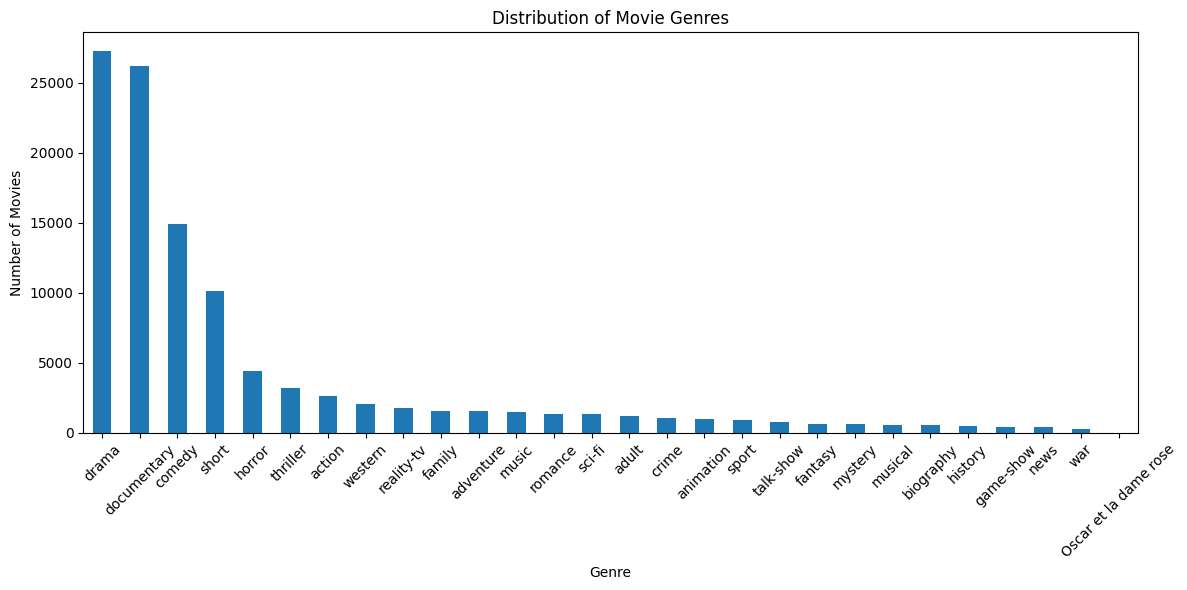

In [48]:
plt.figure(figsize=(12, 6))

genre_counts.plot(kind='bar')

plt.title("Distribution of Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. Select Movie Genres

To keep the classification task manageable, eight well-represented movie genres are selected for the project.

In [49]:
selected_genres = [
    'drama',
    'documentary',
    'comedy',
    'short',
    'horror',
    'thriller',
    'action',
    'western'
]

df = df[df['GENRE'].isin(selected_genres)].copy()

print("Selected genres:")
print(selected_genres)

print("\nDataset shape after genre selection:", df.shape)

Selected genres:
['drama', 'documentary', 'comedy', 'short', 'horror', 'thriller', 'action', 'western']

Dataset shape after genre selection: (90736, 4)


In [50]:
selected_genre_counts = df['GENRE'].value_counts()

print(selected_genre_counts)

GENRE
drama          27224
documentary    26192
comedy         14893
short          10145
horror          4408
thriller        3181
action          2629
western         2064
Name: count, dtype: int64


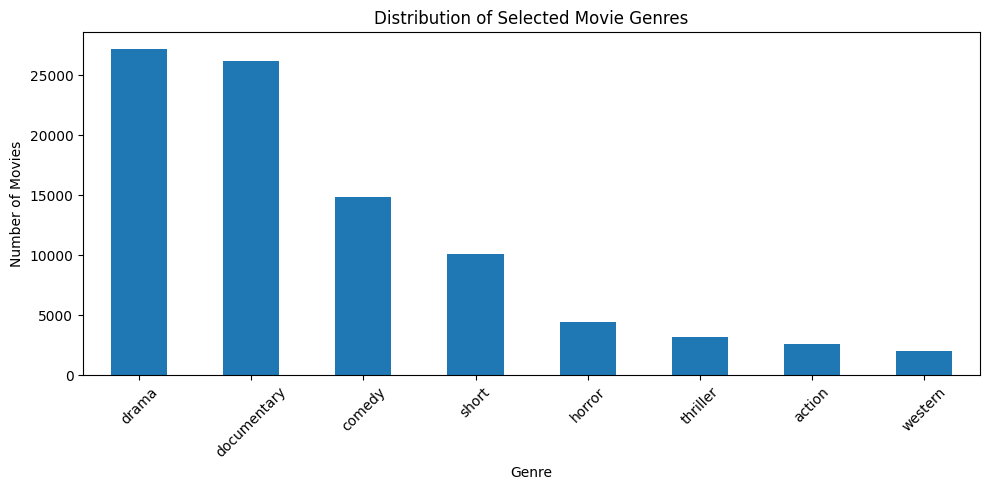

In [52]:
plt.figure(figsize=(10, 5))

selected_genre_counts.plot(kind='bar')

plt.title("Distribution of Selected Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Data Cleaning

In [53]:
df = df.dropna(subset=['DESCRIPTION', 'GENRE'])

df = df.drop_duplicates(subset=['DESCRIPTION'])

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (90496, 4)


In [54]:
df[['TITLE', 'GENRE', 'DESCRIPTION']].head(10)

,TITLE,GENRE,DESCRIPTION
1,Cupid,thriller,A brother and sister with a past incestuous re...
3,The Secret Sin,drama,To help their unemployed father make ends meet...
4,The Unrecovered,drama,The film's title refers not only to the un-rec...
5,Quality Control,documentary,Quality Control consists of a series of 16mm s...
6,"""Pink Slip""",comedy,In tough economic times Max and Joey have all ...
9,Spirits,horror,Four high school students embark on a terrifyi...
10,The Spirit World: Ghana,documentary,Tom Beacham explores Ghana with Director of Ph...
11,In the Gloaming,drama,"Danny, dying of Aids, returns home for his las..."
12,Pink Ribbons: One Small Step,documentary,A sister's breast cancer diagnosis and her bro...
13,Interrabang,thriller,"A photographer is sailing with his wife, her s..."


In [55]:
# Apply preprocessing to all SMS messages

data["clean_message"] = data["message"].apply(preprocess_text)

data.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 10. Text Preprocessing

In [59]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    text = ' '.join(words)

    return text

In [60]:
example = df['DESCRIPTION'].iloc[0]

print("Original Description:")
print(example)

print("\nAfter Preprocessing:")
print(preprocess_text(example))

Original Description:
A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.

After Preprocessing:
brother sister past incestuous relationship current murderous relationship murders women reject murders women get close


In [62]:
df['CLEANED_DESCRIPTION'] = df['DESCRIPTION'].apply(preprocess_text)

df[['DESCRIPTION', 'CLEANED_DESCRIPTION']].head()

,DESCRIPTION,CLEANED_DESCRIPTION
1,A brother and sister with a past incestuous re...,brother sister past incestuous relationship cu...
3,To help their unemployed father make ends meet...,help unemployed father make ends meet edith tw...
4,The film's title refers not only to the un-rec...,films title refers unrecovered bodies ground z...
5,Quality Control consists of a series of 16mm s...,quality control consists series mm single take...
6,In tough economic times Max and Joey have all ...,tough economic times max joey run ideas discov...


In [63]:
df = df[df['CLEANED_DESCRIPTION'].str.strip() != '']

print("Final dataset shape:", df.shape)

Final dataset shape: (90496, 5)


## 11. Prepare Data for Classification

In [64]:
X = df['CLEANED_DESCRIPTION']
y = df['GENRE']

print("Number of input samples:", len(X))
print("Number of target samples:", len(y))
print("Number of classes:", y.nunique())

Number of input samples: 90496
Number of target samples: 90496
Number of classes: 8


## 12. Train-Test Split

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 72396
Testing samples: 18100


## 13. TF-IDF Feature Extraction

In [66]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (72396, 10000)
Testing TF-IDF shape: (18100, 10000)


## 14. Logistic Regression

In [67]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

logistic_predictions = logistic_model.predict(X_test_tfidf)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [68]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 0.6984
Logistic Regression Accuracy: 69.84%


In [69]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      action       0.69      0.34      0.46       525
      comedy       0.65      0.65      0.65      2971
 documentary       0.79      0.88      0.83      5231
       drama       0.65      0.79      0.71      5422
      horror       0.76      0.63      0.69       881
       short       0.59      0.35      0.44      2023
    thriller       0.50      0.15      0.24       635
     western       0.92      0.75      0.83       412

    accuracy                           0.70     18100
   macro avg       0.69      0.57      0.61     18100
weighted avg       0.69      0.70      0.68     18100



## 15. Multinomial Naive Bayes

In [70]:
naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

naive_bayes_predictions = naive_bayes_model.predict(
    X_test_tfidf
)

print("Multinomial Naive Bayes training completed.")

Multinomial Naive Bayes training completed.


In [71]:
naive_bayes_accuracy = accuracy_score(
    y_test,
    naive_bayes_predictions
)

print(f"Naive Bayes Accuracy: {naive_bayes_accuracy:.4f}")
print(f"Naive Bayes Accuracy: {naive_bayes_accuracy * 100:.2f}%")

Naive Bayes Accuracy: 0.6355
Naive Bayes Accuracy: 63.55%


In [72]:
print("Naive Bayes Classification Report:\n")

print(
    classification_report(
        y_test,
        naive_bayes_predictions,
        zero_division=0
    )
)

Naive Bayes Classification Report:

              precision    recall  f1-score   support

      action       0.73      0.11      0.19       525
      comedy       0.66      0.49      0.56      2971
 documentary       0.71      0.88      0.79      5231
       drama       0.55      0.82      0.66      5422
      horror       0.81      0.43      0.56       881
       short       0.68      0.14      0.23      2023
    thriller       0.52      0.02      0.04       635
     western       0.98      0.65      0.78       412

    accuracy                           0.64     18100
   macro avg       0.70      0.44      0.48     18100
weighted avg       0.65      0.64      0.59     18100



## 16. Model Comparison

In [73]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Multinomial Naive Bayes'
    ],
    'Accuracy': [
        logistic_accuracy,
        naive_bayes_accuracy
    ]
})

model_comparison['Accuracy (%)'] = (
    model_comparison['Accuracy'] * 100
)

model_comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.698398,69.839779
1,Multinomial Naive Bayes,0.635470,63.546961


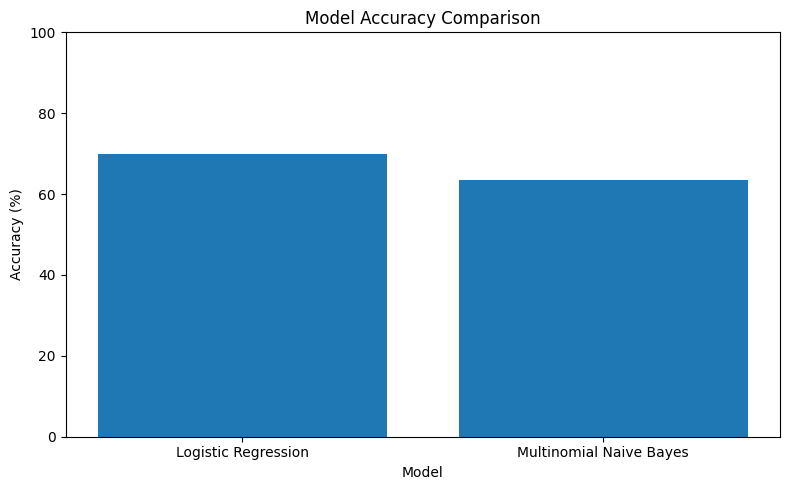

In [74]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['Accuracy (%)']
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## 17. Select the Best Model

In [75]:
if logistic_accuracy >= naive_bayes_accuracy:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_predictions = logistic_predictions
    best_accuracy = logistic_accuracy
else:
    best_model = naive_bayes_model
    best_model_name = "Multinomial Naive Bayes"
    best_predictions = naive_bayes_predictions
    best_accuracy = naive_bayes_accuracy

print("Best Model:", best_model_name)
print(f"Best Model Accuracy: {best_accuracy * 100:.2f}%")

Best Model: Logistic Regression
Best Model Accuracy: 69.84%


## 18. Confusion Matrix

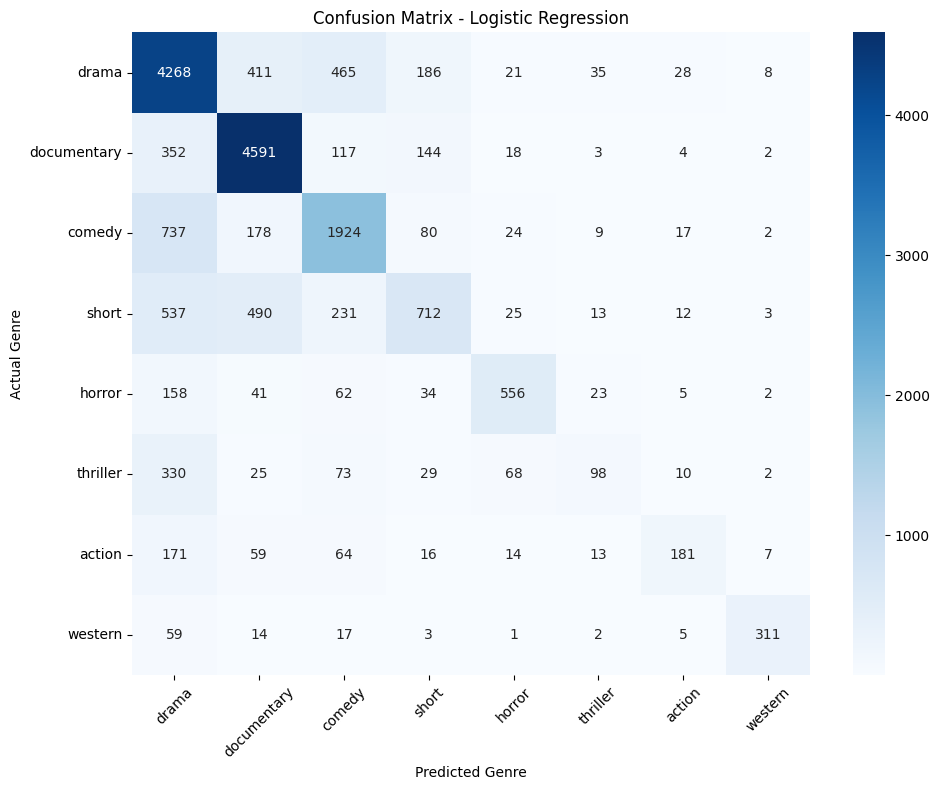

In [76]:
cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=selected_genres
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=selected_genres,
    yticklabels=selected_genres
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 19. Final Model Evaluation

In [77]:
print(f"Final Model: {best_model_name}")
print(f"Accuracy: {best_accuracy * 100:.2f}%\n")

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

Final Model: Logistic Regression
Accuracy: 69.84%

              precision    recall  f1-score   support

      action       0.69      0.34      0.46       525
      comedy       0.65      0.65      0.65      2971
 documentary       0.79      0.88      0.83      5231
       drama       0.65      0.79      0.71      5422
      horror       0.76      0.63      0.69       881
       short       0.59      0.35      0.44      2023
    thriller       0.50      0.15      0.24       635
     western       0.92      0.75      0.83       412

    accuracy                           0.70     18100
   macro avg       0.69      0.57      0.61     18100
weighted avg       0.69      0.70      0.68     18100



## 21. Predict Genre for a New Movie

In [78]:
def predict_movie_genre(description):
    cleaned_description = preprocess_text(description)

    description_tfidf = tfidf_vectorizer.transform(
        [cleaned_description]
    )

    prediction = best_model.predict(
        description_tfidf
    )

    return prediction[0]

In [79]:
new_movie = """
A detective investigates a series of mysterious murders
that have occurred in a small town.
"""

predicted_genre = predict_movie_genre(new_movie)

print("Movie Description:")
print(new_movie)

print("\nPredicted Genre:")
print(predicted_genre)

Movie Description:

A detective investigates a series of mysterious murders
that have occurred in a small town.


Predicted Genre:
horror


## 22. Interactive Movie Genre Prediction

In [80]:
movie_description = input(
    "Enter a movie description: "
)

predicted_genre = predict_movie_genre(
    movie_description
)

print("\nPredicted Movie Genre:", predicted_genre)

Enter a movie description: A group of friends spend the weekend at an abandoned house where strange events begin to happen.

Predicted Movie Genre: horror


In [81]:
test_movies = [

    "A detective follows clues to solve a mysterious murder involving several suspects.",

    "Two people from different backgrounds meet and gradually fall in love.",

    "A family goes on an exciting journey across the country and faces many unexpected adventures."
]

for description in test_movies:
    prediction = predict_movie_genre(description)

    print("Description:")
    print(description)
    print("Predicted Genre:", prediction)
    print("-" * 80)

Description:
A detective follows clues to solve a mysterious murder involving several suspects.
Predicted Genre: thriller
--------------------------------------------------------------------------------
Description:
Two people from different backgrounds meet and gradually fall in love.
Predicted Genre: drama
--------------------------------------------------------------------------------
Description:
A family goes on an exciting journey across the country and faces many unexpected adventures.
Predicted Genre: documentary
--------------------------------------------------------------------------------


## 23. Project Summary

In [82]:
print("==============================================")
print("       MOVIE GENRE CLASSIFICATION")
print("==============================================")

print(f"Original Dataset Size: 108414 movies")
print(f"Final Dataset Size: {len(df)} movies")
print(f"Number of Genres: {y.nunique()}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"TF-IDF Features: {X_train_tfidf.shape[1]}")

print("\nModels Used:")
print("1. Logistic Regression")
print("2. Multinomial Naive Bayes")

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")

print("==============================================")

       MOVIE GENRE CLASSIFICATION
Original Dataset Size: 108414 movies
Final Dataset Size: 90496 movies
Number of Genres: 8
Training Samples: 72396
Testing Samples: 18100
TF-IDF Features: 10000

Models Used:
1. Logistic Regression
2. Multinomial Naive Bayes

Best Model: Logistic Regression
Best Accuracy: 69.84%


## 24. Conclusion

The project developed an NLP-based movie genre classification system using movie descriptions.

The movie descriptions were cleaned and preprocessed before being converted into numerical representations using TF-IDF. Two machine learning algorithms, Logistic Regression and Multinomial Naive Bayes, were trained to classify movies into eight selected genres.

The models were evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. The better-performing model was selected as the final classifier.

The completed system can also accept a new movie description and predict its most likely genre, demonstrating a practical application of NLP and machine learning.